In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

from sklearn import metrics
from sklearn.model_selection import(
    train_test_split,
    GridSearchCV)
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    AdaBoostClassifier,
    GradientBoostingClassifier)

from xgboost import XGBClassifier

In [2]:
creditData = pd.read_csv('credit.csv')
creditData.head(3)

,checking_balance,months_loan_duration,credit_history,purpose,amount,savings_balance,employment_duration,percent_of_income,years_at_residence,age,other_credit,housing,existing_loans_count,job,dependents,phone,default
0,< 0 DM,6,critical,furniture/appliances,1169,unknown,> 7 years,4,4,67,none,own,2,skilled,1,yes,no
1,1 - 200 DM,48,good,furniture/appliances,5951,< 100 DM,1 - 4 years,2,2,22,none,own,1,skilled,1,no,yes
2,unknown,12,critical,education,2096,< 100 DM,4 - 7 years,2,3,49,none,own,1,unskilled,2,no,no


In [3]:
creditData.shape

(1000, 17)

In [4]:
creditData['default'].value_counts()

default
no     700
yes    300
Name: count, dtype: int64

In [5]:
creditData.describe()

,months_loan_duration,amount,percent_of_income,years_at_residence,age,existing_loans_count,dependents
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,20.903000,3271.258000,2.973000,2.845000,35.546000,1.407000,1.155000
std,12.058814,2822.736876,1.118715,1.103718,11.375469,0.577654,0.362086
min,4.000000,250.000000,1.000000,1.000000,19.000000,1.000000,1.000000
25%,12.000000,1365.500000,2.000000,2.000000,27.000000,1.000000,1.000000
50%,18.000000,2319.500000,3.000000,3.000000,33.000000,1.000000,1.000000
75%,24.000000,3972.250000,4.000000,4.000000,42.000000,2.000000,1.000000
max,72.000000,18424.000000,4.000000,4.000000,75.000000,4.000000,2.000000


In [6]:
creditData.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 17 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   checking_balance      1000 non-null   object
 1   months_loan_duration  1000 non-null   int64 
 2   credit_history        1000 non-null   object
 3   purpose               1000 non-null   object
 4   amount                1000 non-null   int64 
 5   savings_balance       1000 non-null   object
 6   employment_duration   1000 non-null   object
 7   percent_of_income     1000 non-null   int64 
 8   years_at_residence    1000 non-null   int64 
 9   age                   1000 non-null   int64 
 10  other_credit          1000 non-null   object
 11  housing               1000 non-null   object
 12  existing_loans_count  1000 non-null   int64 
 13  job                   1000 non-null   object
 14  dependents            1000 non-null   int64 
 15  phone                 1000 non-null   o

In [7]:
# convert object datatypes to categorical
for feature in creditData.columns:
    if creditData[feature].dtype == 'object':
        creditData[feature] = pd.Categorical(creditData[feature])
creditData.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 17 columns):
 #   Column                Non-Null Count  Dtype   
---  ------                --------------  -----   
 0   checking_balance      1000 non-null   category
 1   months_loan_duration  1000 non-null   int64   
 2   credit_history        1000 non-null   category
 3   purpose               1000 non-null   category
 4   amount                1000 non-null   int64   
 5   savings_balance       1000 non-null   category
 6   employment_duration   1000 non-null   category
 7   percent_of_income     1000 non-null   int64   
 8   years_at_residence    1000 non-null   int64   
 9   age                   1000 non-null   int64   
 10  other_credit          1000 non-null   category
 11  housing               1000 non-null   category
 12  existing_loans_count  1000 non-null   int64   
 13  job                   1000 non-null   category
 14  dependents            1000 non-null   int64   
 15  phone

In [8]:
for feature in creditData.columns:
    if creditData[feature].dtype == 'category':
        print(creditData[feature].value_counts())
        print('-'*50)

checking_balance
unknown       394
< 0 DM        274
1 - 200 DM    269
> 200 DM       63
Name: count, dtype: int64
--------------------------------------------------
credit_history
good         530
critical     293
poor          88
very good     49
perfect       40
Name: count, dtype: int64
--------------------------------------------------
purpose
furniture/appliances    473
car                     337
business                 97
education                59
renovations              22
car0                     12
Name: count, dtype: int64
--------------------------------------------------
savings_balance
< 100 DM         603
unknown          183
100 - 500 DM     103
500 - 1000 DM     63
> 1000 DM         48
Name: count, dtype: int64
--------------------------------------------------
employment_duration
1 - 4 years    339
> 7 years      253
4 - 7 years    174
< 1 year       172
unemployed      62
Name: count, dtype: int64
--------------------------------------------------
other_credit
n

In [9]:
replaceStruct = {
    'checking_balance': {'< 0 DM':1,
                         '1 - 200 DM':2,
                         '> 200 DM':3,
                         'unknown':-1},
    'credit_history': {'critical':1,
                       'poor':2,
                       'good':3,
                       'very good':4,
                       'perfect':5},
    'savings_balance': {'< 100 DM':1,
                       '100 - 500 DM':2,
                       '500 - 1000 DM':3,
                       '> 1000 DM':4,
                       'unknown':-1},
    'employment_duration': {'unemployed':1,
                            '< 1 year':2,
                            '1 - 4 years':3,
                            '4 - 7 years':4,
                            '> 7 years':5},
    'phone':{'no':1, 'yes':2},
    #'job': {'unemployed':1,
    #        'unskilled':2,
    #        'skilled':3,
    #        'management':4},
    'default': {'no':0, 'yes':1} # the is the dependent variable
}

oneHotEncoder = ['purpose','housing','other_credit','job']

In [28]:
# Everything needs to be numbers to process models
# create copy of dataset with changes
creditData2 = creditData.copy()
creditData2 = creditData2.replace(replaceStruct)
creditData2 = pd.get_dummies(creditData2, 
                             columns=oneHotEncoder,
                             dtype='int64')
for feature in creditData2.columns:
    if creditData2[feature].dtype == 'category':
        creditData2[feature] = np.int64(creditData2[feature])

creditData2.head(3)

,checking_balance,months_loan_duration,credit_history,amount,savings_balance,employment_duration,percent_of_income,years_at_residence,age,existing_loans_count,...,housing_other,housing_own,housing_rent,other_credit_bank,other_credit_none,other_credit_store,job_management,job_skilled,job_unemployed,job_unskilled
0,1,6,1,1169,-1,5,4,4,67,2,...,0,1,0,0,1,0,0,1,0,0
1,2,48,3,5951,1,3,2,2,22,1,...,0,1,0,0,1,0,0,1,0,0
2,-1,12,1,2096,1,4,2,3,49,1,...,0,1,0,0,1,0,0,0,0,1


In [29]:
creditData2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 29 columns):
 #   Column                        Non-Null Count  Dtype
---  ------                        --------------  -----
 0   checking_balance              1000 non-null   int64
 1   months_loan_duration          1000 non-null   int64
 2   credit_history                1000 non-null   int64
 3   amount                        1000 non-null   int64
 4   savings_balance               1000 non-null   int64
 5   employment_duration           1000 non-null   int64
 6   percent_of_income             1000 non-null   int64
 7   years_at_residence            1000 non-null   int64
 8   age                           1000 non-null   int64
 9   existing_loans_count          1000 non-null   int64
 10  dependents                    1000 non-null   int64
 11  phone                         1000 non-null   int64
 12  default                       1000 non-null   int64
 13  purpose_business              1000

# Split the data into train and test sets

In [30]:
X = creditData2.drop('default', axis=1)
y = creditData2['default']

In [31]:
(X_train, X_test,
 y_train, y_test) = train_test_split(X,
                                     y,
                                     test_size=0.3,
                                     stratify=y,
                                     random_state=1)

In [32]:
# Function to create confusion matrix
def make_confusion_matrix(model,y_actual,labels=[1, 0]):
    '''
    model : classifier to predict values of X
    y_actual : ground truth  
    
    '''
    y_predict = model.predict(X_test)
    cm=metrics.confusion_matrix( y_actual, y_predict, labels=[0, 1])
    df_cm = pd.DataFrame(cm, index = [i for i in ["Actual - No","Actual - Yes"]],
                  columns = [i for i in ['Predicted - No','Predicted - Yes']])
    group_counts = ["{0:0.0f}".format(value) for value in
                cm.flatten()]
    group_percentages = ["{0:.2%}".format(value) for value in
                         cm.flatten()/np.sum(cm)]
    labels = [f"{v1}\n{v2}" for v1, v2 in
              zip(group_counts,group_percentages)]
    labels = np.asarray(labels).reshape(2,2)
    plt.figure(figsize = (10,7))
    sns.heatmap(df_cm, annot=labels,fmt='')
    plt.ylabel('True label')
    plt.xlabel('Predicted label')

In [33]:
#  Function to calculate different metric scores of the model - Accuracy, Recall and Precision
def get_metrics_score(model,flag=True):
    '''
    model : classifier to predict values of X

    '''
    # defining an empty list to store train and test results
    score_list=[] 
    
    pred_train = model.predict(X_train)
    pred_test = model.predict(X_test)
    
    train_acc = model.score(X_train,y_train)
    test_acc = model.score(X_test,y_test)
    
    train_recall = metrics.recall_score(y_train,pred_train)
    test_recall = metrics.recall_score(y_test,pred_test)
    
    train_precision = metrics.precision_score(y_train,pred_train)
    test_precision = metrics.precision_score(y_test,pred_test)
    
    score_list.extend((train_acc,test_acc,train_recall,test_recall,train_precision,test_precision))
        
    # If the flag is set to True then only the following print statements will be dispayed. The default value is set to True.
    if flag == True: 
        print("Accuracy on training set : ",model.score(X_train,y_train))
        print("Accuracy on test set : ",model.score(X_test,y_test))
        print("Recall on training set : ",metrics.recall_score(y_train,pred_train))
        print("Recall on test set : ",metrics.recall_score(y_test,pred_test))
        print("Precision on training set : ",metrics.precision_score(y_train,pred_train))
        print("Precision on test set : ",metrics.precision_score(y_test,pred_test))
    
    return score_list # returning the list with train and test scores

## Building the models

### AdaBoost Classifier - Default Parameters

Accuracy on training set :  0.7985714285714286
Accuracy on test set :  0.75
Recall on training set :  0.5571428571428572
Recall on test set :  0.4777777777777778
Precision on training set :  0.7090909090909091
Precision on test set :  0.6056338028169014


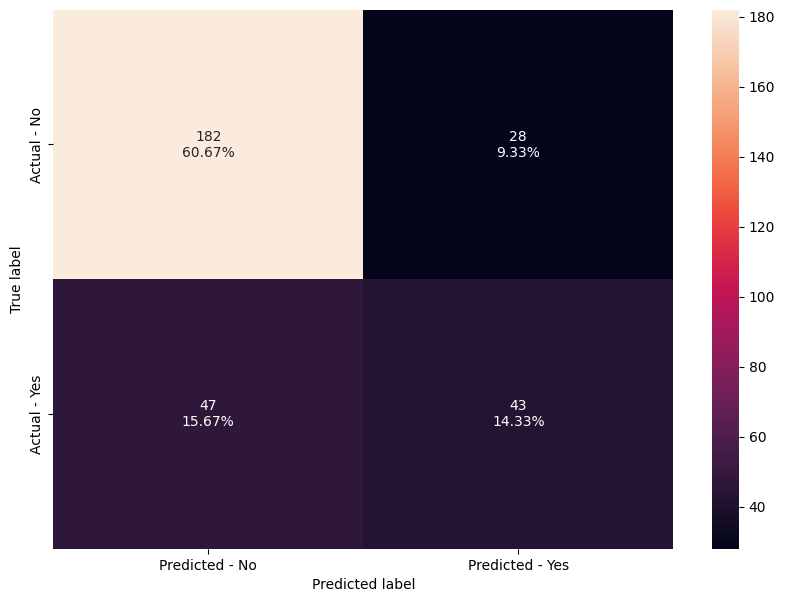

In [36]:
abc = AdaBoostClassifier(random_state=1).fit(X_train, y_train)
abc_score=get_metrics_score(abc)
make_confusion_matrix(abc, y_test)

### Gradient Boosting Classifer - Default Parameters

Accuracy on training set :  0.9085714285714286
Accuracy on test set :  0.7266666666666667
Recall on training set :  0.7476190476190476
Recall on test set :  0.4444444444444444
Precision on training set :  0.9345238095238095
Precision on test set :  0.5555555555555556


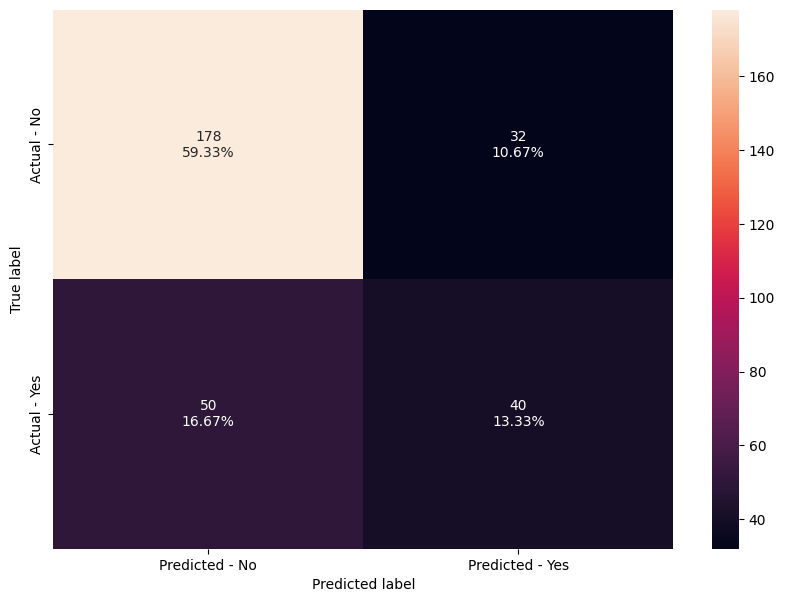

In [38]:
gbc = GradientBoostingClassifier(random_state=1).fit(X_train, y_train)
gbc_score = get_metrics_score(gbc)
make_confusion_matrix(gbc, y_test)

### XGBoost Classifier - Default parameters

Accuracy on training set :  1.0
Accuracy on test set :  0.7533333333333333
Recall on training set :  1.0
Recall on test set :  0.5222222222222223
Precision on training set :  1.0
Precision on test set :  0.6025641025641025


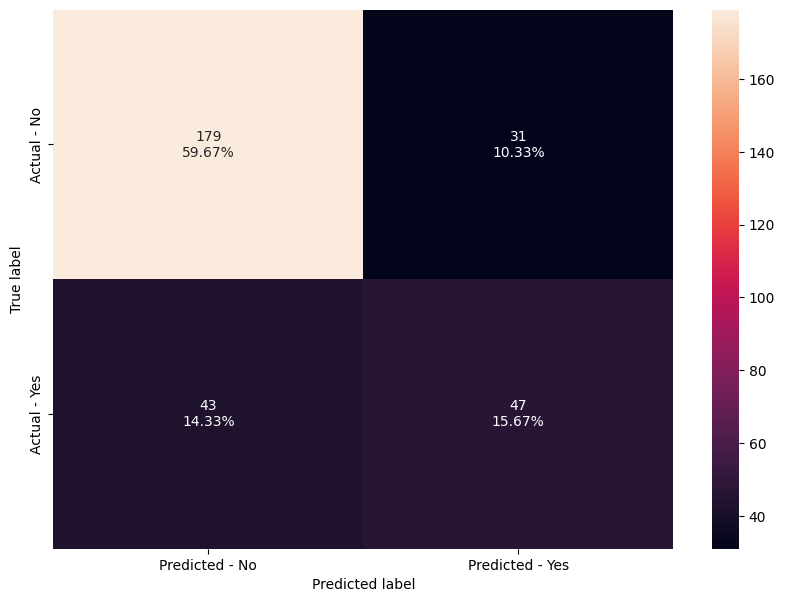

In [40]:
xgb = XGBClassifier(random_state=1, eval_metric='logloss').fit(X_train,y_train)
xgb_score=get_metrics_score(xgb)
make_confusion_matrix(xgb, y_test)

## Hyperparameter Tuning

### AdaBoost Classifier

In [45]:
abc_tuned = AdaBoostClassifier(random_state=1)

parameters = {
    'estimator':[DecisionTreeClassifier(max_depth=1,
                                             random_state=1),
                      DecisionTreeClassifier(max_depth=2,
                                             random_state=1),
                      DecisionTreeClassifier(max_depth=3,
                                             random_state=1)],
    'n_estimators': np.arange(10,110,10),
    'learning_rate': np.arange(0.1,2,0.1)}

acc_scorer = metrics.make_scorer(metrics.recall_score)

grid_obj = GridSearchCV(abc_tuned,
                        parameters,
                        scoring = acc_scorer,
                        cv=5).fit(X_train, y_train)
abc_tuned = grid_obj.best_estimator_
abc_tuned.fit(X_train, y_train)

AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=3,
                                                    random_state=1),
                   learning_rate=1.8000000000000003, n_estimators=10,
                   random_state=1)

In [46]:
abc_tuned_score = get_metrics_score(abc_tuned)

Accuracy on training set :  0.8342857142857143
Accuracy on test set :  0.6733333333333333
Recall on training set :  0.7
Recall on test set :  0.4888888888888889
Precision on training set :  0.735
Precision on test set :  0.4583333333333333


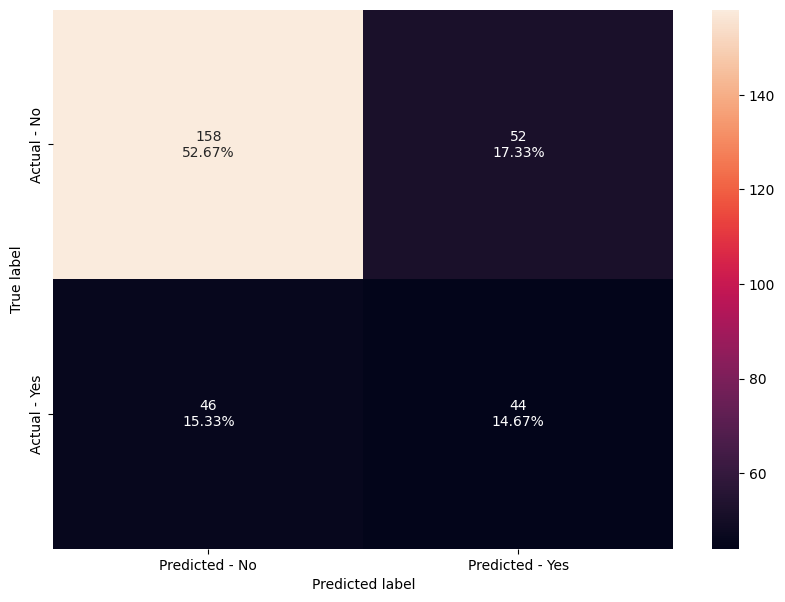

In [47]:
make_confusion_matrix(abc_tuned, y_test)

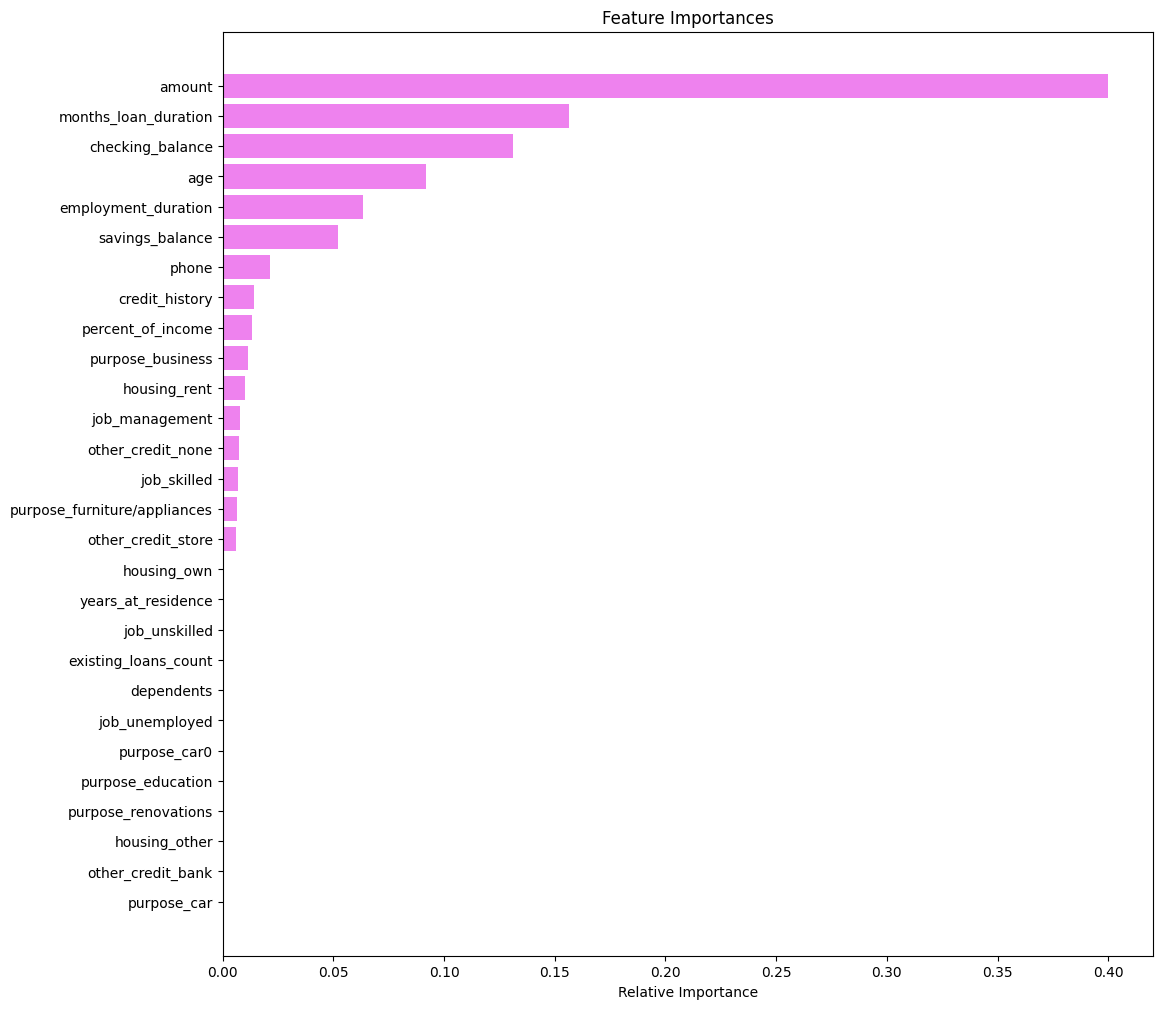

In [50]:
importances = abc_tuned.feature_importances_
indices = np.argsort(importances)
feature_names = list(X.columns)


plt.figure(figsize=(12,12))
plt.barh(range(len(indices)),
         importances[indices],
         color='violet',
         align='center')
plt.yticks(range(len(indices)), 
           [feature_names[i] for i in indices])
plt.xlabel('Relative Importance')
plt.title('Feature Importances')
plt.show()

### Gradient Boosting Classifier

In [51]:
gbc_init = GradientBoostingClassifier(init=AdaBoostClassifier(random_state=1),random_state=1)
gbc_init.fit(X_train, y_train)

GradientBoostingClassifier(init=AdaBoostClassifier(random_state=1),
                           random_state=1)

In [52]:
gbc_init_score = get_metrics_score(gbc_init)

Accuracy on training set :  0.9128571428571428
Accuracy on test set :  0.7466666666666667
Recall on training set :  0.7428571428571429
Recall on test set :  0.5222222222222223
Precision on training set :  0.9570552147239264
Precision on test set :  0.5875


In [54]:
gbc_tuned = GradientBoostingClassifier(init=AdaBoostClassifier(random_state=1),random_state=1)

parameters = {
    'n_estimators':[100,150,200,250],
    'subsample':[0.8, 0.9, 1],
    'max_features': [0.7,0.8,0.9]
}

acc_scorer = metrics.make_scorer(metrics.recall_score)
grid_obj = GridSearchCV(gbc_tuned,
                        parameters,
                        scoring=acc_scorer,
                        cv=5).fit(X_train, y_train)
gbc_tuned = grid_obj.best_estimator_
gbc_tuned.fit(X_train, y_train)

GradientBoostingClassifier(init=AdaBoostClassifier(random_state=1),
                           max_features=0.9, n_estimators=150, random_state=1,
                           subsample=0.8)

In [55]:
gbc_tuned_score = get_metrics_score(gbc_tuned)

Accuracy on training set :  0.9542857142857143
Accuracy on test set :  0.7466666666666667
Recall on training set :  0.8714285714285714
Recall on test set :  0.5111111111111111
Precision on training set :  0.973404255319149
Precision on test set :  0.5897435897435898


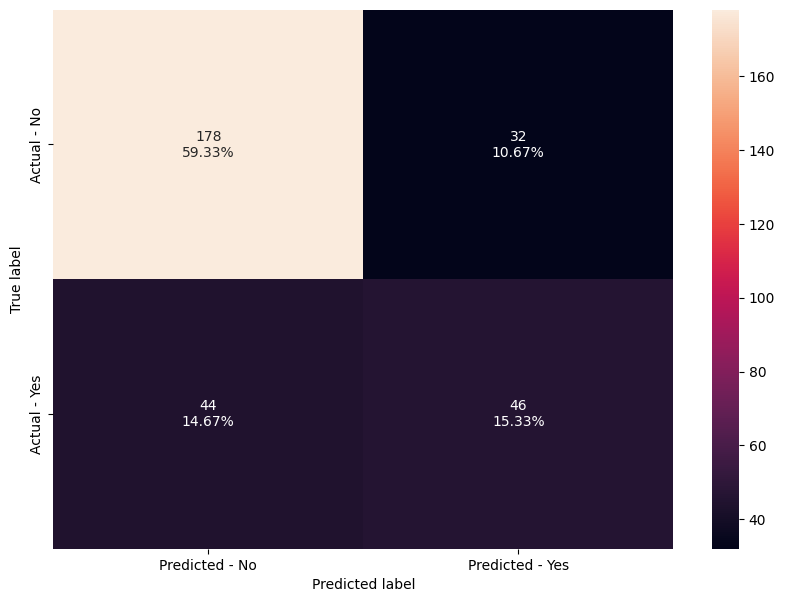

In [56]:
make_confusion_matrix(gbc_tuned, y_test)

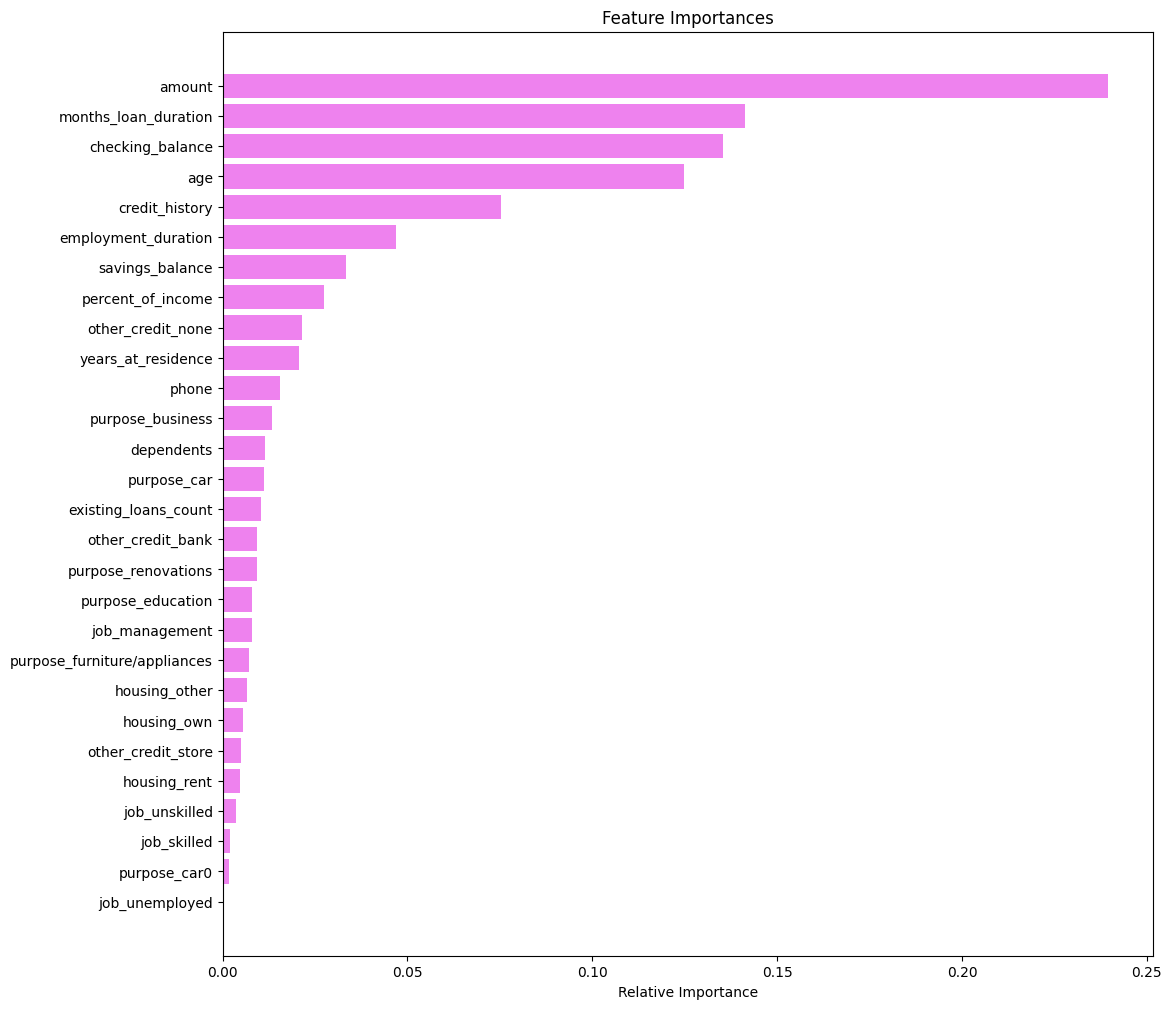

In [58]:
importances = gbc_tuned.feature_importances_
indices = np.argsort(importances)
feature_names = list(X.columns)

plt.figure(figsize=(12,12))
plt.barh(range(len(indices)),
         importances[indices],
         color='violet',
         align='center')
plt.yticks(range(len(indices)),
           [feature_names[i] for i in indices])
plt.xlabel('Relative Importance')
plt.title('Feature Importances')
plt.show()

### XGBoost Classifier

In [63]:
xgb_tuned = XGBClassifier(random_state=1, eval_metric='logloss')

parameters = {
    'n_estimators': np.arange(10,100,20),
    'scale_pos_weight':[0,1,2,5],
    'subsample':[0.5,0.7,0.9,1],
    'learning_rate':[0.01,0.05,0.1,0.2],
    'gamma':[0,1,3],
    'colsample_bytree':[0.5,0.7,0.9,1],
    'colsample_bylevel':[0.5,0.7,0.9,1]
}

acc_scorer = metrics.make_scorer(metrics.recall_score)
grid_obj = GridSearchCV(xgb_tuned,
                      parameters,
                      scoring=acc_scorer,
                      cv=5).fit(X_train,y_train)
xgb_tuned = grid_obj.best_estimator_
xgb_tuned.fit(X_train, y_train)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=0.5, colsample_bynode=None,
              colsample_bytree=0.5, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, gamma=0, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.01, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=10,
              n_jobs=None, num_parallel_tree=None, random_state=1, ...)

In [64]:
xgb_tuned_score=get_metrics_score(xgb_tuned)

Accuracy on training set :  0.3
Accuracy on test set :  0.3
Recall on training set :  1.0
Recall on test set :  1.0
Precision on training set :  0.3
Precision on test set :  0.3


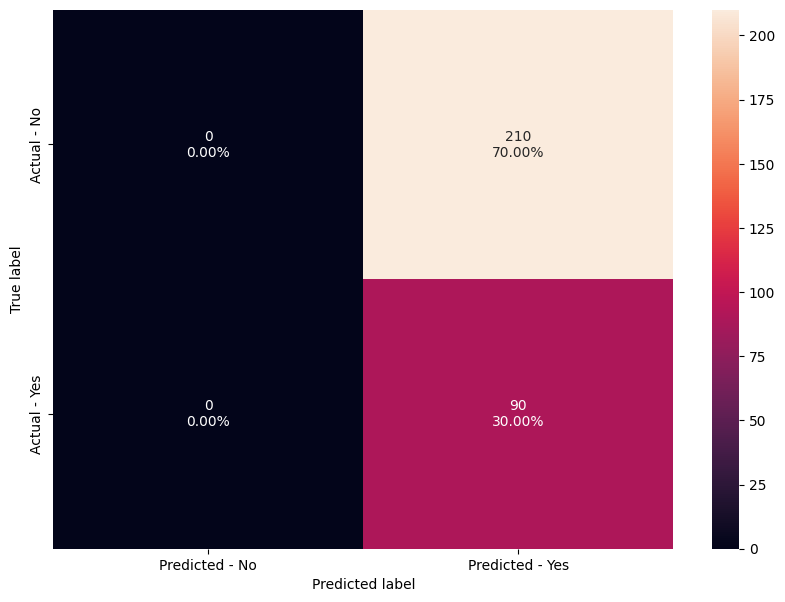

In [65]:
make_confusion_matrix(xgb_tuned,y_test)

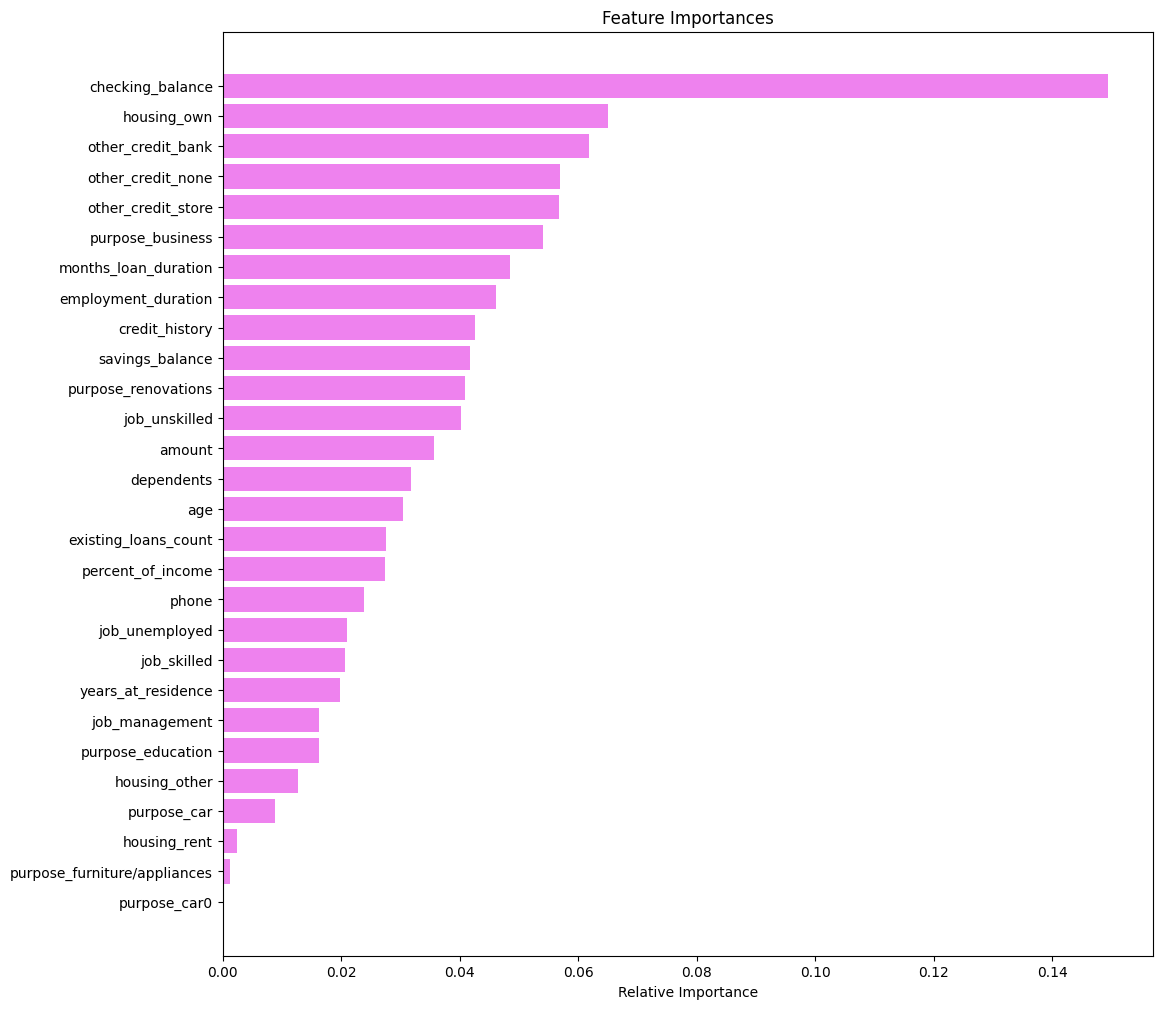

In [66]:
importances = xgb_tuned.feature_importances_
indices = np.argsort(importances)
feature_names = list(X.columns)

plt.figure(figsize=(12,12))
plt.title('Feature Importances')
plt.barh(range(len(indices)), importances[indices], color='violet', align='center')
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel('Relative Importance')
plt.show()

## Comparing All Models

In [67]:
# defining list of models
models = [abc, abc_tuned, gbc, gbc_init, gbc_tuned, xgb, xgb_tuned]

# defining empty lists to add train and test results
acc_train = []
acc_test = []
recall_train = []
recall_test = []
precision_train = []
precision_test = []

# looping through all the models to get the accuracy, precall and precision scores
for model in models:
    j = get_metrics_score(model,False)
    acc_train.append(np.round(j[0],2))
    acc_test.append(np.round(j[1],2))
    recall_train.append(np.round(j[2],2))
    recall_test.append(np.round(j[3],2))
    precision_train.append(np.round(j[4],2))
    precision_test.append(np.round(j[5],2))

In [68]:
comparison_frame = pd.DataFrame({'Model':['AdaBoost with default paramters','AdaBoost Tuned', 
                                          'Gradient Boosting with default parameters','Gradient Boosting with init=AdaBoost',
                                          'Gradient Boosting Tuned','XGBoost with default parameters','XGBoost Tuned'], 
                                          'Train_Accuracy': acc_train,'Test_Accuracy': acc_test,
                                          'Train_Recall':recall_train,'Test_Recall':recall_test,
                                          'Train_Precision':precision_train,'Test_Precision':precision_test}) 
comparison_frame

,Model,Train_Accuracy,Test_Accuracy,Train_Recall,Test_Recall,Train_Precision,Test_Precision
0,AdaBoost with default paramters,0.80,0.75,0.56,0.48,0.71,0.61
1,AdaBoost Tuned,0.83,0.67,0.70,0.49,0.74,0.46
2,Gradient Boosting with default parameters,0.91,0.73,0.75,0.44,0.93,0.56
3,Gradient Boosting with init=AdaBoost,0.91,0.75,0.74,0.52,0.96,0.59
4,Gradient Boosting Tuned,0.95,0.75,0.87,0.51,0.97,0.59
5,XGBoost with default parameters,1.00,0.75,1.00,0.52,1.00,0.60
6,XGBoost Tuned,0.30,0.30,1.00,1.00,0.30,0.30
